# Tarefa 2

1. Monte um passo a passo para o algoritmo RF
2. Explique com suas palavras o Random forest
3. Qual a diferença entre Bagging e Random
Forest?
4. (Opcional) Implementar em python o Random
Forest
– Bootstrap
– Feature selection
– Modelagem com Decision trees
– Agregação

### 1. Monte um passo a passo para o algoritmo RF

- Definir o problema

Identifique se o problema é de classificação (ex: prever categorias) ou regressão (ex: prever números contínuos).

- Coleta e preparação dos dados

Obtenha os dados, faça a limpeza: tratamento de nulos, codificação de variáveis categóricas, normalização (quando necessário) e separe os dados em variáveis independentes (features) e variável dependente (target).

- Divisão entre treino e teste

Divida os dados em conjunto de treino e teste (ex: 80% treino, 20% teste). Isso permite avaliar o desempenho do modelo com dados "novos".

- Criação do modelo Random Forest

Para classificação: RandomForestClassifier. Para regressão: RandomForestRegressor. Defina os hiperparâmetros principais, como número de árvores (n_estimators) e profundidade (max_depth), se necessário.

- Treinamento do modelo

Alimente o modelo com os dados de treino para que ele aprenda os padrões dos dados.

- Realização de previsões

Use o modelo treinado para prever os dados do conjunto de teste.

- Avaliação do modelo

Para classificação: Acurácia, matriz de confusão, precisão, recall, etc. Para regressão: Erro médio (MSE, RMSE, MAE), R², etc.

### 2. Explique com suas palavras o Random forest

O Random Forest é um algoritmo de aprendizado de máquina supervisionado que combina várias árvores de decisão para tomar decisões mais precisas e estáveis. Cada árvore da floresta é treinada com uma amostra aleatória dos dados e utiliza apenas parte das variáveis disponíveis, o que garante diversidade entre elas. Na hora da previsão, cada árvore "vota" (no caso de classificação) ou contribui com um valor (no caso de regressão), e o resultado final é baseado na maioria dos votos ou na média dos valores. Essa abordagem reduz o risco de overfitting e melhora a robustez do modelo, tornando o Random Forest eficaz em diferentes tipos de problemas e dados.


### 3. Qual a diferença entre Bagging e Random Forest?

A principal diferença entre Bagging e Random Forest é que, enquanto o Bagging treina múltiplos modelos (geralmente árvores de decisão) em amostras aleatórias dos dados e combina suas previsões para reduzir a variância, o Random Forest é uma variação do Bagging que, além de usar amostras aleatórias de dados, seleciona aleatoriamente um subconjunto de variáveis em cada divisão de cada árvore. Isso introduz uma maior diversidade entre as árvores, o que ajuda a melhorar a precisão e a reduzir o risco de overfitting, tornando o Random Forest geralmente mais eficaz que o Bagging em muitos casos.


### 4. (Opcional) Implementar em python o Random Forest
– Bootstrap
– Feature selection
– Modelagem com Decision trees
– Agregação

Acurácia: 1.0000

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



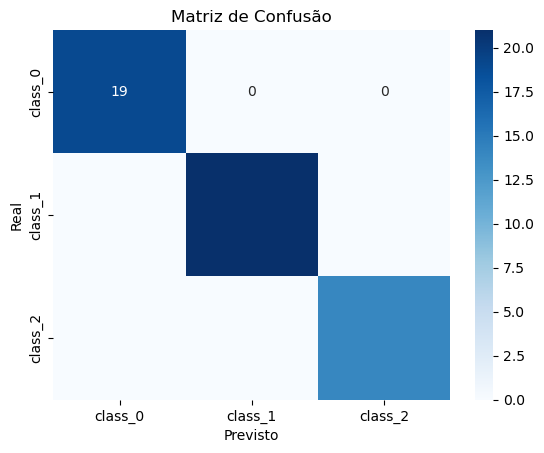

Importância da feature alcohol: 0.1420
Importância da feature malic_acid: 0.0290
Importância da feature ash: 0.0119
Importância da feature alcalinity_of_ash: 0.0332
Importância da feature magnesium: 0.0347
Importância da feature total_phenols: 0.0598
Importância da feature flavanoids: 0.1659
Importância da feature nonflavanoid_phenols: 0.0055
Importância da feature proanthocyanins: 0.0298
Importância da feature color_intensity: 0.1802
Importância da feature hue: 0.0860
Importância da feature od280/od315_of_diluted_wines: 0.0960
Importância da feature proline: 0.1261


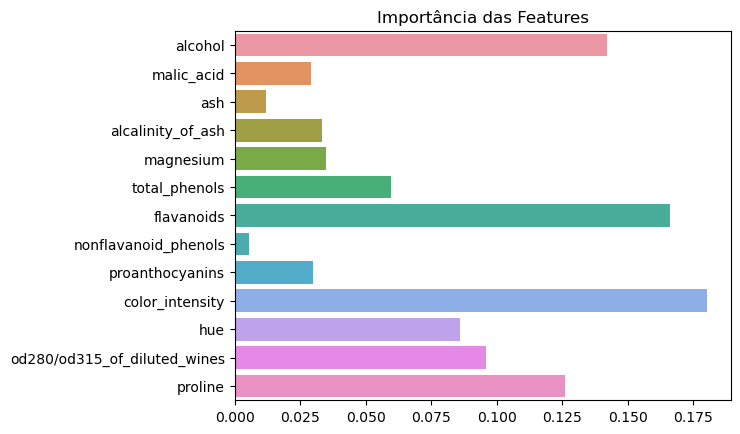

In [9]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# 1. Carregar o Wine Dataset
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 2. Dividir os dados em treino e teste (70% treino e 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Criar e treinar o modelo Random Forest com parâmetros customizados
# - max_features=3: Seleção aleatória de 3 features por árvore (Feature Selection)
random_forest = RandomForestClassifier(n_estimators=100, max_features=3, random_state=42)
random_forest.fit(X_train, y_train)

# 4. Fazer previsões com o modelo treinado
y_pred = random_forest.predict(X_test)

# 5. Avaliar o modelo: Acurácia, Matriz de Confusão e Relatório de Classificação
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Matriz de Confusão")
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# 6. Importância das Features
importances = random_forest.feature_importances_
for feature, importance in zip(X.columns, importances):
    print(f"Importância da feature {feature}: {importance:.4f}")

# Gráfico de Importância das Features
sns.barplot(x=importances, y=X.columns)
plt.title("Importância das Features")
plt.show()
